# CNN vs Vision Transformer vs Vision Mamba
## Three Generations of Visual Architectures — A Systematic Comparison

**Course**: CDS521 Foundation of Artificial Intelligence
**Topic**: RNN/Transformer-related Application + CNN + Advanced Training Techniques

This notebook provides a complete pipeline:
1. **Data preparation** — CIFAR-100 with standard augmentation
2. **Model training** — ResNet-18, DeiT-Tiny, Vim-Tiny (and more)
3. **Accuracy comparison** — Top-1/Top-5 on the same test set
4. **Efficiency benchmarks** — FLOPs, latency, peak memory
5. **Robustness analysis** — FGSM adversarial attacks
6. **Visualization** — Grad-CAM heatmaps, t-SNE feature spaces

---

## 0. Setup & Installation

In [1]:
import os, sys, subprocess
IN_COLAB = 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ
if IN_COLAB:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "timm", "fvcore", "grad-cam", "gradio", "einops"])
    print('Colab setup complete!')
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cpu


## 1. Data Preparation

/Users/chaowang/foundationai-pro/.venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Classes: 100 | Train batches: 351 | Test batches: 79


/Users/chaowang/foundationai-pro/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


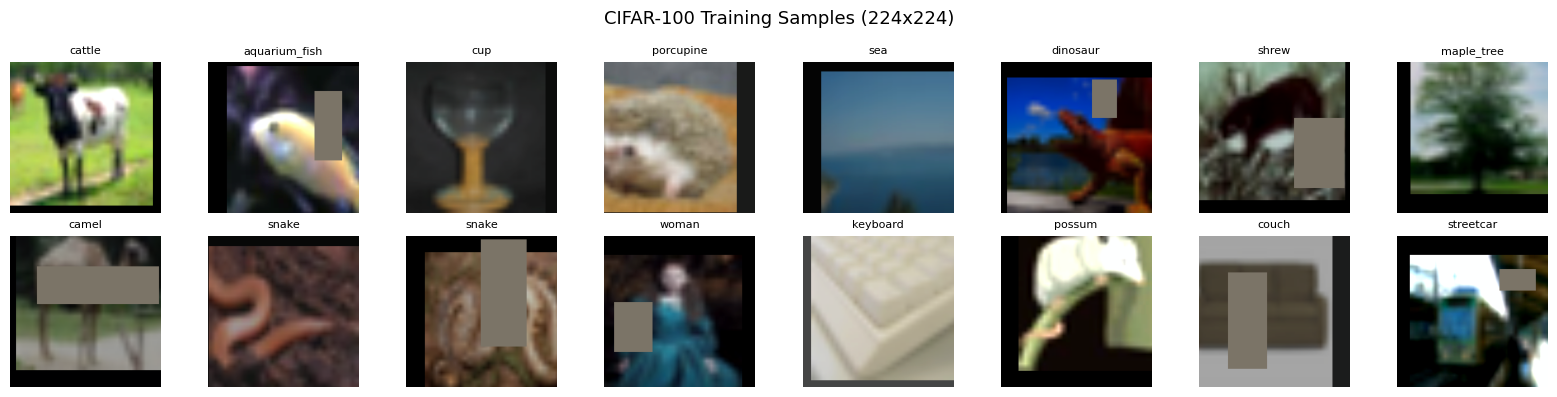

In [2]:
from data.dataset import get_cifar100_dataloaders, get_class_names

train_loader, val_loader, test_loader, num_classes = get_cifar100_dataloaders(
    data_dir='../data/datasets', image_size=224, batch_size=128, num_workers=2,
)
class_names = get_class_names('cifar100')
print(f'Classes: {num_classes} | Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

# Visualize samples
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0).numpy() * std + mean
    ax.imshow(np.clip(img, 0, 1)); ax.set_title(class_names[labels[i]], fontsize=8); ax.axis('off')
plt.suptitle('CIFAR-100 Training Samples (224x224)', fontsize=13)
plt.tight_layout(); plt.show()

## 2. Model Overview — Parameter Counts

In [3]:
from models.build_model import build_model, count_parameters, list_models, get_model_family

print(f'{"Model":<32s} | {"Family":<6s} | {"Params":>10s}')
print('-' * 55)
for name in list_models():
    m = build_model(name, num_classes=100)
    n = count_parameters(m)
    print(f'  {name:<30s} | {get_model_family(name):<6s} | {n/1e6:>7.2f}M')
    del m

/Users/chaowang/foundationai-pro/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model                            | Family |     Params
-------------------------------------------------------
  resnet18                       | cnn    |   11.23M
  resnet50                       | cnn    |   23.71M
  convnext_tiny                  | cnn    |   27.90M
  deit_tiny_patch16_224          | vit    |    5.54M
  deit_small_patch16_224         | vit    |   21.70M
  vim_tiny                       | mamba  |    6.92M
  vim_small                      | mamba  |   26.23M


## 3. Training — One model from each family
Train ResNet-18 (CNN), DeiT-Tiny (ViT), Vim-Tiny (Mamba) on CIFAR-100.

In [ ]:
from training.trainer import train

MODELS_TO_TRAIN = ['resnet18', 'deit_tiny', 'vim_tiny']
all_results = {}
for config_name in MODELS_TO_TRAIN:
    results = train(config_name)
    all_results[config_name] = results


  Model: resnet18  |  Family: cnn
  Device: cpu


100%|██████████| 169M/169M [08:35<00:00, 328kB/s]    
/Users/chaowang/foundationai-pro/.venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


  Dataset: CIFAR-100 | Train: 45000 | Val: 40 batches | Test: 79 batches


/Users/chaowang/foundationai-pro/notebooks/../training/trainer.py:184: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=config.training.mixed_precision and device.type == "cuda")


  Parameters: 11,227,812 (11.23M)

  Starting training for 50 epochs...



Train Epoch 1:   0%|          | 0/351 [00:00<?, ?it/s]/Users/chaowang/foundationai-pro/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/chaowang/foundationai-pro/notebooks/../training/trainer.py:83: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
Train Epoch 1:   1%|          | 2/351 [01:25<3:57:22, 40.81s/it, acc1=1.17%, loss=4.6506]

## 4. Results — Accuracy Comparison & Training Curves

In [ ]:
from visualization.plots import generate_comparison_table, plot_training_curves

print(generate_comparison_table(all_results))
fig = plot_training_curves(all_results, save_path='../outputs/training_curves.png')
plt.show()

## 5. Efficiency Benchmarks — FLOPs, Latency, Memory

In [ ]:
from evaluation.efficiency import benchmark_model
from visualization.plots import plot_pareto_front

efficiency_results = []
for cfg_name in MODELS_TO_TRAIN:
    mname = all_results[cfg_name]['model_name']
    m = build_model(mname, num_classes=100)
    bench = benchmark_model(m, mname, device=str(device))
    bench['family'] = get_model_family(mname)
    bench['test_acc1'] = all_results[cfg_name]['test_acc1']
    efficiency_results.append(bench)
    del m

fig = plot_pareto_front(efficiency_results, save_path='../outputs/pareto_front.png')
plt.show()

## 6. Adversarial Robustness (FGSM Attack)

In [ ]:
from evaluation.robustness import evaluate_fgsm_robustness
from visualization.plots import plot_robustness_comparison

fgsm_results = {}
for cfg_name in MODELS_TO_TRAIN:
    mname = all_results[cfg_name]['model_name']
    m = build_model(mname, num_classes=100)
    ckpt = Path(f'../outputs/{mname}/best.pth')
    if ckpt.exists():
        m.load_state_dict(torch.load(ckpt, map_location='cpu', weights_only=True))
    m = m.to(device)
    print(f'\nFGSM Robustness — {mname}')
    fgsm_results[mname] = evaluate_fgsm_robustness(m, test_loader, device, epsilons=(0, 0.005, 0.01, 0.02, 0.05))
    del m

fig = plot_robustness_comparison(fgsm_results, save_path='../outputs/robustness_fgsm.png')
plt.show()

## 7. Grad-CAM — What does each architecture look at?

In [ ]:
from visualization.grad_cam import plot_gradcam_comparison, get_target_layer

models_viz = {}
for cfg_name in MODELS_TO_TRAIN:
    mname = all_results[cfg_name]['model_name']
    m = build_model(mname, num_classes=100)
    ckpt = Path(f'../outputs/{mname}/best.pth')
    if ckpt.exists():
        m.load_state_dict(torch.load(ckpt, map_location='cpu', weights_only=True))
    m = m.to(device)
    tl = get_target_layer(m, mname)
    models_viz[mname] = (m, tl)

test_imgs, test_lbls = next(iter(test_loader))
samples = [test_imgs[i:i+1] for i in range(4)]
fig = plot_gradcam_comparison(samples, models_viz, device, class_names=class_names, save_path='../outputs/gradcam.png')
plt.show()

## 8. t-SNE Feature Space Comparison

In [ ]:
from visualization.tsne import plot_tsne_comparison

models_tsne = {}
for cfg_name in MODELS_TO_TRAIN:
    mname = all_results[cfg_name]['model_name']
    m = build_model(mname, num_classes=100)
    ckpt = Path(f'../outputs/{mname}/best.pth')
    if ckpt.exists():
        m.load_state_dict(torch.load(ckpt, map_location='cpu', weights_only=True))
    models_tsne[mname] = m.to(device)

fig = plot_tsne_comparison(models_tsne, test_loader, device, max_samples=1500, n_classes_to_show=10, save_path='../outputs/tsne.png')
plt.show()

## 9. Summary

After running the experiments above, fill in the table with actual numbers:

| Metric | ResNet-18 (CNN) | DeiT-Tiny (ViT) | Vim-Tiny (Mamba) |
|--------|:-:|:-:|:-:|
| Test Acc@1 | TBD | TBD | TBD |
| Test Acc@5 | TBD | TBD | TBD |
| Params (M) | 11.2 | 5.7 | ~7 |
| FLOPs (G) | TBD | TBD | TBD |
| Latency (ms) | TBD | TBD | TBD |
| FGSM@0.01 | TBD | TBD | TBD |

### Key Takeaways
- CNN: best at ... (fill after experiments)
- ViT: best at ... (fill after experiments)
- Mamba: best at ... (fill after experiments)

## 8. t-SNE Feature Space Comparison